# Paper Figures Generation

This notebook reproduces the **6 figures** shown in the paper from saved flow checkpoints
and the representative training datasets in `representative data/`.

| # | Figure | Output file (in `figure_paper/`) |
|---|--------|----------------------------------|
| 1 | Joint marginals — Isobar vs Flow scatter | `fig1_joint_marginals_scatter_<kind>.pdf` |
| 2 | SDP scatter with conditional slices around it | `fig2_conditionals_around_main_<kind>.pdf` |
| 3 | $\mathcal{C}(m',\theta')$ and $\mathcal{S}^2(m',\theta')$ four-panel | `fig3_C_and_S2_combined.pdf` |
| 4 | Ensemble 4-panel (Isobar / Flow mean / residuals / coverage) | `fig4_ensemble_4panel_<kind>.pdf` |
| 5 | CP-even ensemble 4-panel | `fig5_cp_even_4panel.pdf` |
| 6 | CP-odd ensemble 4-panel | `fig6_cp_odd_4panel.pdf` |

The notebook is parameterized by `FLOW_KIND` (one of `flavor` / `even` / `odd`) for figures 1, 2, 4.
Figure 3 is intrinsically a flavor-side comparison built from CP-even and CP-odd flows.
Figures 5 and 6 are intrinsically CP-even and CP-odd respectively.


## 1. Setup

Imports, config, and utility helpers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import shutil

sns.set()
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
USE_TEX = shutil.which('latex') is not None
plt.rcParams['text.usetex'] = USE_TEX
print(f"Matplotlib text rendering: {'LaTeX' if USE_TEX else 'mathtext fallback'}")

import torch
from torch import nn

from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import (
    CompositeTransform, InverseTransform,
    PiecewiseRationalQuadraticCouplingTransform,
    RandomPermutation,
    Sigmoid,
)

from Amplitude import DKpp, AmpSample, SquareDalitzPlot2
from DKpp import DKppCorrelated

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

FIG_DIR = Path('figure_paper')
FIG_DIR.mkdir(exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR.resolve()}")

Matplotlib text rendering: LaTeX
Using cpu device
Figures will be saved to: /Users/san/Library/CloudStorage/OneDrive-CornellUniversity/Extraction-of-Gamma-with-Normalising-flows/figure_paper


### Flow factory and checkpoint loader

In [2]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features, hidden=64, layers=2, output_scale=0.30):
        super().__init__()
        feats = [nn.Linear(in_features, hidden), nn.SiLU()]
        for _ in range(layers - 1):
            feats += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*feats)
        self.head = nn.Linear(hidden, out_features)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        self.output_scale = output_scale

    def forward(self, x, context=None):
        h = self.backbone(x)
        return self.head(h) * self.output_scale


def create_flow(on_unit_box=True, num_flows=12, hidden_features=128, num_bins=24, device=None):
    """Rational-quadratic neural spline flow on [0,1]^2 — matches training architecture."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    dim = 2
    transforms = []
    if on_unit_box:
        sigmoid = Sigmoid()
        if hasattr(sigmoid, "temperature") and isinstance(sigmoid.temperature, torch.Tensor):
            sigmoid.temperature = sigmoid.temperature.to(device)
        if hasattr(sigmoid, "eps") and isinstance(sigmoid.eps, torch.Tensor):
            sigmoid.eps = sigmoid.eps.to(device)
        transforms.append(InverseTransform(sigmoid))
    masks = [torch.tensor([1, 0], dtype=torch.bool), torch.tensor([0, 1], dtype=torch.bool)]
    for i in range(num_flows):
        def _conditioner(in_f, out_f, _h=hidden_features):
            return MLP(in_f, out_f, hidden=_h, layers=2)
        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=masks[i % 2], transform_net_create_fn=_conditioner,
                num_bins=num_bins, tails="linear", tail_bound=5.0,
                apply_unconditional_transform=False,
            )
        )
        transforms.append(RandomPermutation(features=dim))
    return Flow(transform=CompositeTransform(transforms), distribution=StandardNormal([dim]))


def load_flow_state_compat(flow, path, map_location=None):
    """Load checkpoint, tolerating Sigmoid buffer differences across nflows versions."""
    state = torch.load(path, map_location=map_location)
    model_state = flow.state_dict()
    missing = [k for k in model_state.keys() if k not in state]
    unexpected = [k for k in state.keys() if k not in model_state]
    allowed = ("temperature", "eps")
    bad_m = [k for k in missing if not any(t in k for t in allowed)]
    bad_u = [k for k in unexpected if not any(t in k for t in allowed)]
    if bad_m or bad_u:
        raise RuntimeError(f"Checkpoint mismatch. Missing: {bad_m[:5]} Unexpected: {bad_u[:5]}")
    for k in missing: state[k] = model_state[k]
    for k in unexpected: state.pop(k)
    flow.load_state_dict(state, strict=False)
    return flow

### Configuration

`FLOW_KIND` selects which mode (`flavor`, `even`, `odd`) is used for figures that depend on it
(Figures 1, 2, 4). For the paper, all three are `flavor`.

In [3]:
FLOW_KIND = "flavor"   # one of: "flavor", "even", "odd"

N_SAMPLES = 2_000_000      # flow events drawn for the scatter figure (matches training data size)
N_DENSITY_GRID = 250       # grid for figures 1 (density panel context) and 4 utilities
N_MARGINAL_X = 400
N_MARGINAL_Y = 800
N_ENSEMBLE_GRID = 300      # grid for ensemble computations (figures 4, 5, 6)
N_SEEDS = 25               # ensemble size
SLICE_VALUES = np.linspace(0.2, 0.8, 4)

# Symmetric SDP convention
idx = (2, 3, 1)
mD, mKs, mpi = 1.86483, 0.497611, 0.13957018
sdp_obj = SquareDalitzPlot2(mD, mKs, mpi, mpi)
_sum_m2 = sdp_obj.mSq[0] + sdp_obj.mSq[1] + sdp_obj.mSq[2] + sdp_obj.mSq[3]

dkpp_flavor = DKpp()
dkpp_even = DKppCorrelated(cp=+1)
dkpp_odd  = DKppCorrelated(cp=-1)

FLOW_CONFIG = {
    "flavor": {"title": r"Flavor $D^0$", "ckpt": "flavor_SDP_sym_2e6/trial_seed1.pth", "exact_model": dkpp_flavor},
    "even":   {"title": r"CP-even $D_+$", "ckpt": "even_SDP_sym_2e6/trial_seed1.pth",   "exact_model": dkpp_even},
    "odd":    {"title": r"CP-odd $D_-$",  "ckpt": "odd_SDP_sym_2e6/trial_seed1.pth",    "exact_model": dkpp_odd},
}
cfg = FLOW_CONFIG[FLOW_KIND]
print(f"FLOW_KIND = {FLOW_KIND}: {cfg['title']}, ckpt={cfg['ckpt']}")

FLOW_KIND = flavor: Flavor $D^0$, ckpt=flavor_SDP_sym_2e6/trial_seed1.pth


### SDP / DP coordinate utilities and exact density

In [4]:
def _finite_pos(x, eps=1e-14):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    return np.maximum(x, eps)


def dp_to_sdp(points_dp, sdp_obj=sdp_obj, idx=idx):
    i, j, k = idx
    s12, s13 = points_dp[:, 0], points_dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    mp = np.vectorize(lambda a, b: sdp_obj.MpfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    tp = np.vectorize(lambda a, b: sdp_obj.TfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    return np.column_stack([mp, tp])


def sdp_to_dp(points_sdp, sdp_obj=sdp_obj, idx=idx):
    i, j, k = idx
    out = np.empty_like(points_sdp, dtype=float)
    for n, (mp, tp) in enumerate(points_sdp):
        s23, s12 = sdp_obj.M_from_MpT(mp, tp, i, j, k)
        out[n, 0] = s12
        out[n, 1] = _sum_m2 - s23 - s12
    return out


def exact_sdp_density_raw(points_sdp, kind=FLOW_KIND):
    dp = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    amp = FLOW_CONFIG[kind]["exact_model"].full(np.column_stack([s12, s13]))
    i, j, k = idx
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k)) for n in range(len(points_sdp))])
    invJ = _finite_pos(1.0 / J)
    return np.abs(amp) ** 2 * invJ


_exact_norm_cache = {}

def exact_norm(kind=FLOW_KIND, n_grid=350):
    key = (kind, n_grid)
    if key not in _exact_norm_cache:
        eps = 1e-6
        u = np.linspace(eps, 1.0 - eps, n_grid)
        v = np.linspace(eps, 1.0 - eps, n_grid)
        U, V = np.meshgrid(u, v, indexing="xy")
        pts = np.column_stack([U.ravel(), V.ravel()])
        dens = exact_sdp_density_raw(pts, kind=kind).reshape(len(v), len(u))
        norm = np.trapz(np.trapz(dens, u, axis=1), v, axis=0)
        _exact_norm_cache[key] = norm
    return _exact_norm_cache[key]


def exact_sdp_density(points_sdp, kind=FLOW_KIND):
    return exact_sdp_density_raw(points_sdp, kind=kind) / exact_norm(kind=kind)


@torch.no_grad()
def pdf_from_flow(pts, flow, device=device, batch=65536):
    pts_t = torch.from_numpy(np.asarray(pts, dtype=np.float32)).to(device)
    outs = []
    flow = flow.to(device).eval()
    for i in range(0, len(pts_t), batch):
        outs.append(flow.log_prob(pts_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    return np.exp(logp)


def get_checkpoint_path(kind, seed):
    base = {'flavor': 'flavor_SDP_sym_2e6', 'even': 'even_SDP_sym_2e6', 'odd': 'odd_SDP_sym_2e6'}
    return f"{base[kind]}/trial_seed{seed}.pth"


def exact_density_grid(kind=FLOW_KIND, n_grid=N_DENSITY_GRID, eps=1e-6):
    u = np.linspace(eps, 1.0 - eps, n_grid)
    v = np.linspace(eps, 1.0 - eps, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])
    dens = exact_sdp_density(pts, kind=kind).reshape(len(v), len(u))
    return u, v, dens


@torch.no_grad()
def flow_density_grid(flow, n_grid=N_DENSITY_GRID, eps=1e-6, batch=65536, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    u = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    v = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()]).astype(np.float32)
    pts_t = torch.from_numpy(pts).to(device)
    outs = []
    flow = flow.to(device).eval()
    for i in range(0, len(pts_t), batch):
        outs.append(flow.log_prob(pts_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    return u, v, np.exp(logp).reshape(len(v), len(u))


@torch.no_grad()
def marginal_likelihood(flow, axis=0, xs=None, nx=400, ny=800, eps=1e-8, batch=65536, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    flow = flow.to(device).eval()
    xmin, xmax = eps, 1.0 - eps
    ymin, ymax = eps, 1.0 - eps
    if xs is None:
        xs = np.linspace(xmin, xmax, nx, dtype=np.float32)
    else:
        xs = np.asarray(xs, dtype=np.float32); nx = xs.shape[0]
    ys = np.linspace(ymin, ymax, ny, dtype=np.float32)
    if axis == 0:
        XX = np.tile(xs, (ny, 1)); YY = np.tile(ys[:, None], (1, nx))
    else:
        XX = np.tile(ys[:, None], (1, nx)); YY = np.tile(xs, (ny, 1))
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(device)
    outs = []
    for i in range(0, grid_t.shape[0], batch):
        outs.append(flow.log_prob(grid_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).view(ny, nx)
    dy = (ymax - ymin) / (ny - 1)
    log_marg = torch.logsumexp(logp, dim=0) + torch.log(torch.tensor(dy, device=device))
    return xs, np.exp(log_marg.detach().cpu().numpy())


@torch.no_grad()
def conditional_pdf(flow, fixed_value, fixed_axis=0, nx=400, eps=1e-8, batch=65536, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    flow = flow.to(device).eval()
    xs = np.linspace(eps, 1.0 - eps, nx, dtype=np.float32)
    fixed = np.full_like(xs, fixed_value)
    if fixed_axis == 0:
        grid = np.column_stack([fixed, xs]).astype(np.float32)
    else:
        grid = np.column_stack([xs, fixed]).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(device)
    outs = []
    for i in range(0, grid_t.shape[0], batch):
        outs.append(flow.log_prob(grid_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    pdf = np.exp(logp)
    return xs, pdf / np.trapz(pdf, xs)


def exact_conditional_theta_given_mprime(mprime, kind=FLOW_KIND, n_theta=400):
    theta = np.linspace(1e-6, 1.0 - 1e-6, n_theta)
    pts = np.column_stack([np.full_like(theta, mprime), theta])
    pdf = exact_sdp_density(pts, kind=kind)
    return theta, pdf / np.trapz(pdf, theta)


def exact_conditional_mprime_given_theta(theta, kind=FLOW_KIND, n_mprime=400):
    mprime = np.linspace(1e-6, 1.0 - 1e-6, n_mprime)
    pts = np.column_stack([mprime, np.full_like(mprime, theta)])
    pdf = exact_sdp_density(pts, kind=kind)
    return mprime, pdf / np.trapz(pdf, mprime)


@torch.no_grad()
def compute_ensemble_density_grid(kind, n_grid=N_ENSEMBLE_GRID, n_seeds=N_SEEDS, eps=1e-6, batch=65536, device=None, verbose=True):
    """Pointwise mean and std of density across an ensemble of `n_seeds` flow checkpoints."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    u = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    v = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()]).astype(np.float32)
    pts_t = torch.from_numpy(pts).to(device)
    all_dens = []
    it = tqdm(range(n_seeds), desc=f'Loading {kind} ensemble') if verbose else range(n_seeds)
    for seed in it:
        flow_i = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
        flow_i = load_flow_state_compat(flow_i, get_checkpoint_path(kind, seed), map_location=device)
        flow_i = flow_i.to(device).eval()
        outs = []
        for i in range(0, len(pts_t), batch):
            outs.append(flow_i.log_prob(pts_t[i:i + batch]))
        all_dens.append(np.exp(torch.cat(outs, dim=0).cpu().numpy()))
        del flow_i
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    all_dens = np.stack(all_dens, axis=0)
    return u, v, all_dens.mean(0).reshape(len(v), len(u)), all_dens.std(0).reshape(len(v), len(u))


@torch.no_grad()
def ensemble_density_at_points(kind, points, n_seeds=N_SEEDS, batch=65536, device=None, desc=None):
    """Per-point mean and std of density evaluated at supplied points across the ensemble."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    pts_t = torch.from_numpy(points.astype(np.float32)).to(device)
    all_dens = []
    for seed in tqdm(range(n_seeds), desc=desc or f'Ensemble at points ({kind})'):
        flow_i = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
        flow_i = load_flow_state_compat(flow_i, get_checkpoint_path(kind, seed), map_location=device)
        flow_i = flow_i.to(device).eval()
        outs = []
        for i in range(0, len(pts_t), batch):
            outs.append(flow_i.log_prob(pts_t[i:i + batch]))
        all_dens.append(np.exp(torch.cat(outs, dim=0).cpu().numpy()))
        del flow_i
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    all_dens = np.stack(all_dens, axis=0)
    return all_dens.mean(0), all_dens.std(0)

### Load primary flow and representative training data

The representative dataset is the same dataset_001 used during training. Loading it (rather than
regenerating from the isobar amplitude) keeps the figures reproducible across runs.

In [5]:
flow = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow = load_flow_state_compat(flow, cfg["ckpt"], map_location=device)
flow = flow.to(device).eval()
print(f"Loaded flow checkpoint: {cfg['ckpt']}  ({sum(p.numel() for p in flow.parameters()):,} params)")

mp_thetap = np.load(f'representative data/dataset_001_{FLOW_KIND}.npy')
print(f"Loaded representative isobar reference sample: {len(mp_thetap):,} events")

with torch.no_grad():
    mp_thetap_gen = flow.sample(N_SAMPLES).cpu().numpy()
mp_thetap_gen = np.clip(mp_thetap_gen, 1e-6, 1.0 - 1e-6)
print(f"Generated flow events: {len(mp_thetap_gen):,}")

Loaded flow checkpoint: flavor_SDP_sym_2e6/trial_seed1.pth  (311,124 params)
Loaded representative isobar reference sample: 2,000,000 events


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Generated flow events: 2,000,000


## Figure 1 — Joint marginals (Isobar vs Flow scatter)

Side-by-side scatter of the two samples in $(m', \theta')$ with the projected marginals on the
top/right axes. The exact (isobar) marginals are computed analytically; the flow marginals are
obtained by integrating the learned density.

In [6]:
# Density grid (used for marginal computation), and 1D flow marginals
mprime_exact, theta_exact, dens_exact_2d = exact_density_grid(FLOW_KIND)
_, _, dens_flow_2d = flow_density_grid(flow, device=device)
dens_m_exact = np.trapz(dens_exact_2d, theta_exact, axis=0)
dens_theta_exact = np.trapz(dens_exact_2d, mprime_exact, axis=1)

mprime_flow, dens_m_flow = marginal_likelihood(flow, axis=0, nx=N_MARGINAL_X, ny=N_MARGINAL_Y, device=device)
theta_flow, dens_theta_flow = marginal_likelihood(flow, axis=1, nx=N_MARGINAL_X, ny=N_MARGINAL_Y, device=device)

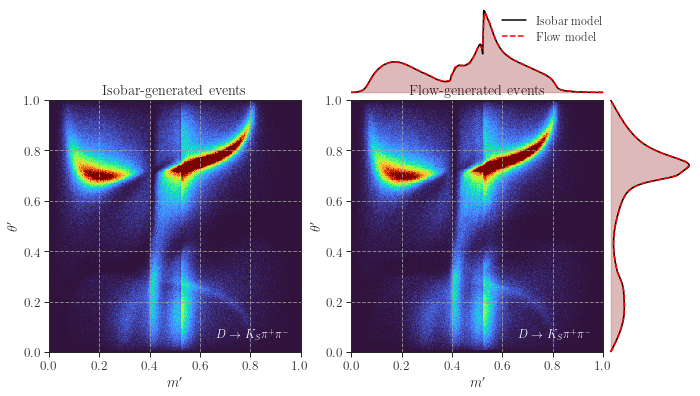

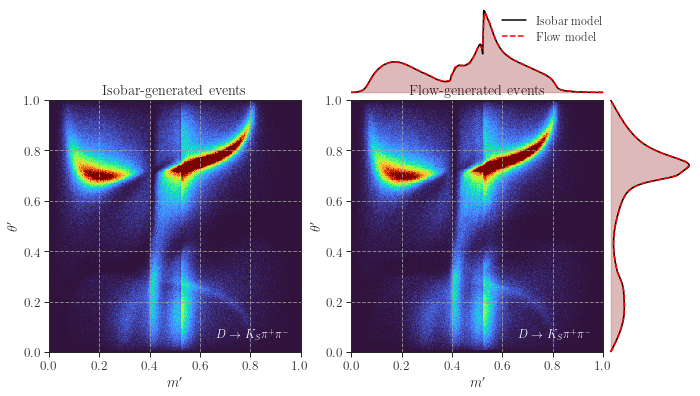

In [7]:
import importlib, symmetric_figure_helpers
importlib.reload(symmetric_figure_helpers)
from symmetric_figure_helpers import (
    plot_joint_marginals_samples,
    plot_conditionals_around_main,
    plot_C_and_S2_combined,
)

plot_joint_marginals_samples(
    exact_samples=mp_thetap,
    flow_samples=mp_thetap_gen,
    mprime_exact=mprime_exact,
    theta_exact=theta_exact,
    dens_m_exact=dens_m_exact,
    dens_theta_exact=dens_theta_exact,
    mprime_flow=mprime_flow,
    theta_flow=theta_flow,
    dens_m_flow=dens_m_flow,
    dens_theta_flow=dens_theta_flow,
    title_left="Isobar-generated events",
    title_right="Flow-generated events",
    sample_label=None,
    savepath=str(FIG_DIR / f"fig1_joint_marginals_scatter_{FLOW_KIND}.pdf"),
)

## Figure 2 — SDP scatter with conditional slices

Central panel: 2D scatter of isobar samples. Around it: 1D conditional PDFs at fixed $m'$
(top, four panels) and at fixed $\theta'$ (right, four panels). Solid black is the exact
isobar model; dashed red is the flow.

/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


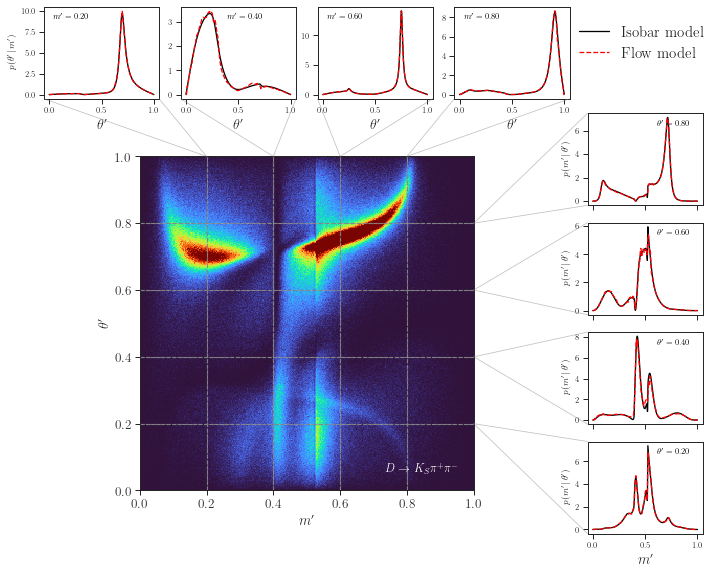

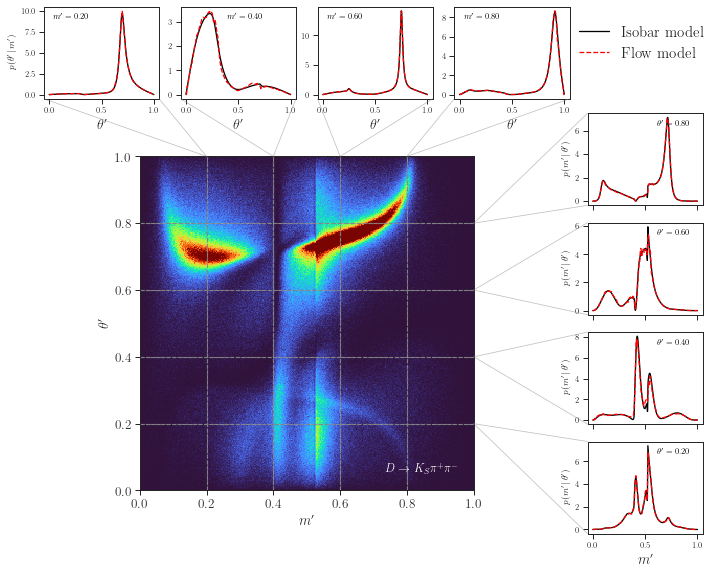

In [8]:
def conditional_pdf_for_helpers(*, fixed_value, fixed_axis, nx=400):
    return conditional_pdf(flow, fixed_value=fixed_value, fixed_axis=fixed_axis, nx=nx, device=device)

plot_conditionals_around_main(
    exact_samples=mp_thetap,
    flow_samples=mp_thetap_gen,
    flow=flow,
    mprime_slices=SLICE_VALUES,
    theta_slices=SLICE_VALUES,
    exact_conditional_theta_given_mprime=exact_conditional_theta_given_mprime,
    exact_conditional_mprime_given_theta=exact_conditional_mprime_given_theta,
    conditional_pdf_func=conditional_pdf_for_helpers,
    sample_label=None,
    savepath=str(FIG_DIR / f"fig2_conditionals_around_main_{FLOW_KIND}.pdf"),
)

## Figure 3 — $\mathcal{C}(m',\theta')$ and $\mathcal{S}^2(m',\theta')$

The CP-symmetric interference term $\mathcal{C}$ and squared coherence $\mathcal{S}^2 = K\bar K - \mathcal{C}^2$
are reconstructed two ways:
- **Isobar** (left column): from the analytic amplitude.
- **Flow** (right column): $\mathcal{C}$ from a CP-even and CP-odd flow,
  $\mathcal{S}^2$ from those plus the flavor flow.

This figure is independent of `FLOW_KIND` — it always loads CP-even, CP-odd, and flavor flows.

Gamma_+ = 949.677261    Gamma_- = 2008.213303


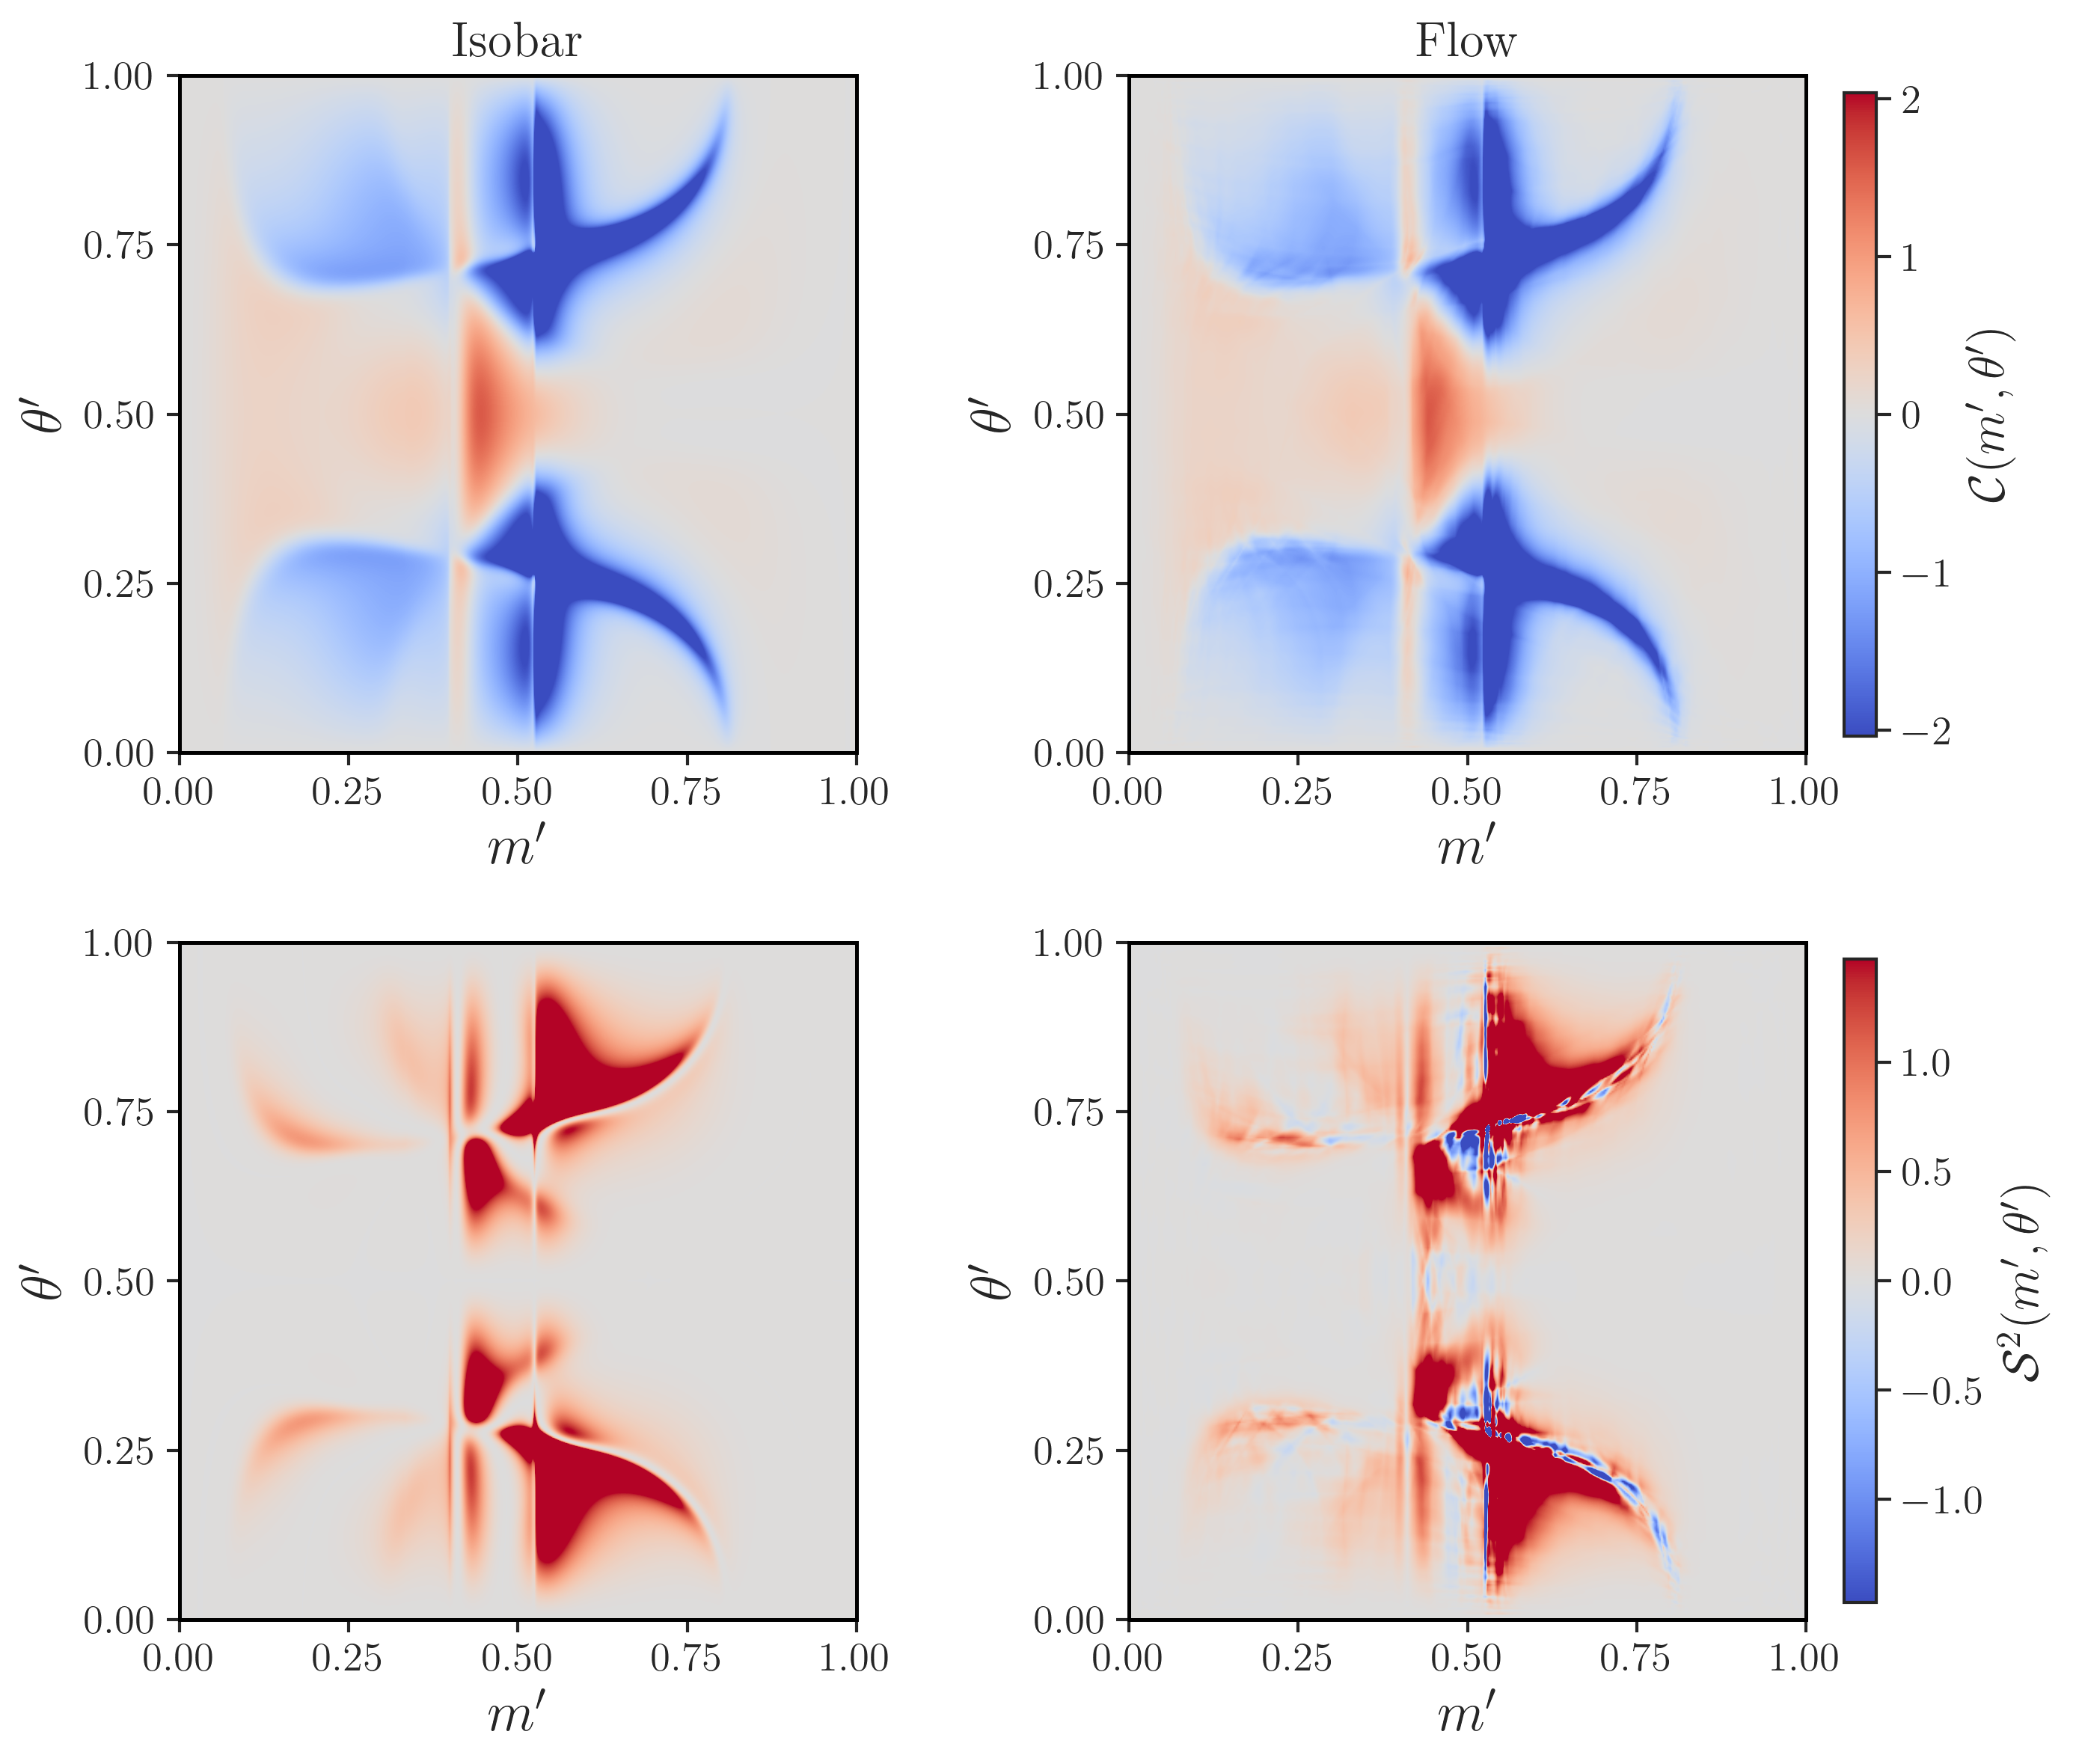

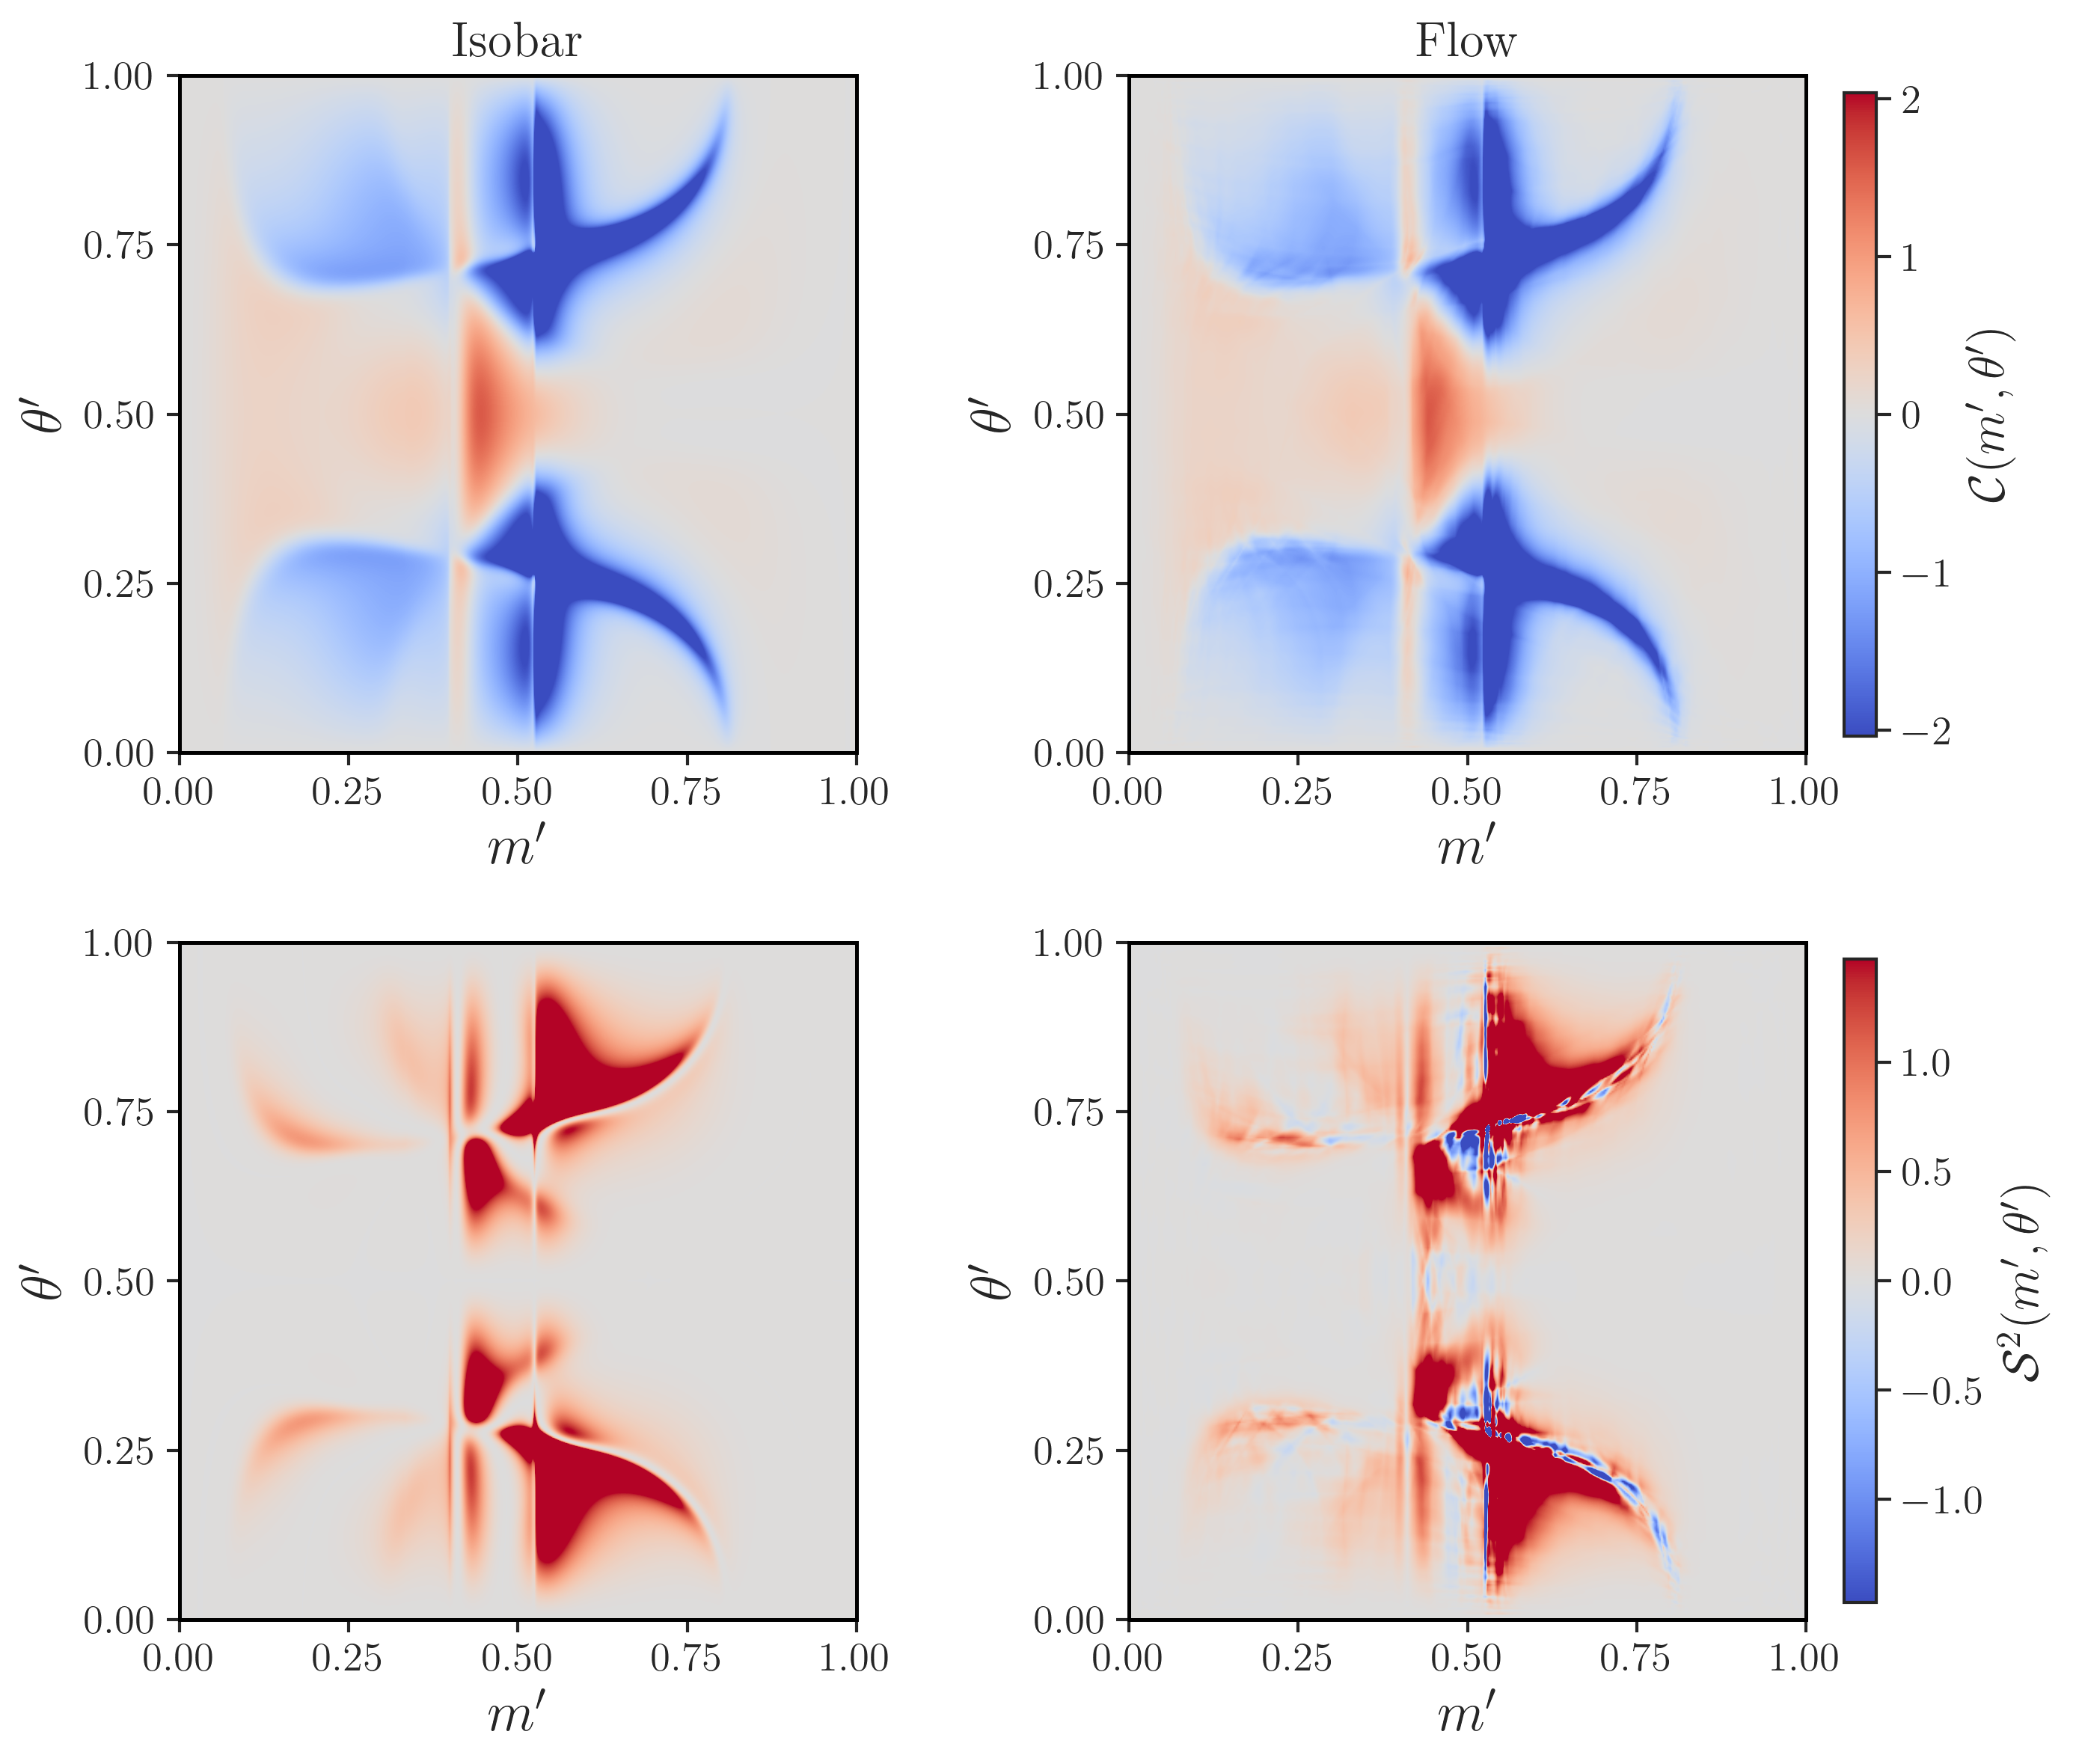

In [9]:
def make_sdp_grid(nx=400, ny=400, eps=1e-6):
    u = np.linspace(eps, 1.0 - eps, nx)
    v = np.linspace(eps, 1.0 - eps, ny)
    U, V = np.meshgrid(u, v, indexing='xy')
    return U, V, np.column_stack([U.ravel(), V.ravel()])


def compute_Gamma_pm_sym(dkpp_model=dkpp_flavor, n_grid=500):
    u = np.linspace(1e-6, 1.0 - 1e-6, n_grid)
    v = np.linspace(1e-6, 1.0 - 1e-6, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])
    dp = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    I_plus = np.abs(A12 + A13s) ** 2
    I_minus = np.abs(A12 - A13s) ** 2
    i, j, k = idx
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k)) for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)
    dA = (1.0 / (n_grid - 1)) ** 2
    return np.sum(I_plus * invJ) * dA, np.sum(I_minus * invJ) * dA


def compute_C_exact_sym(pts, dkpp_model=dkpp_flavor, Gamma_plus=None, Gamma_minus=None):
    if Gamma_plus is None or Gamma_minus is None:
        Gamma_plus, Gamma_minus = compute_Gamma_pm_sym(dkpp_model=dkpp_model)
    dp = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    i, j, k = idx
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k)) for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)
    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    return 4.0 * np.real(A12 * np.conjugate(A13s)) * invJ / (Gamma_plus + Gamma_minus)


def compute_C_flow_sym(pts, flow_even, flow_odd, Gamma_plus, Gamma_minus, device=device):
    f_even = pdf_from_flow(pts, flow_even, device=device)
    f_odd  = pdf_from_flow(pts, flow_odd,  device=device)
    return (Gamma_plus * f_even - Gamma_minus * f_odd) / (Gamma_plus + Gamma_minus)


# Load the three flows needed for figure 3
flow_even_C = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_even_C = load_flow_state_compat(flow_even_C, FLOW_CONFIG['even']['ckpt'], map_location=device).to(device).eval()

flow_odd_C = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_odd_C = load_flow_state_compat(flow_odd_C, FLOW_CONFIG['odd']['ckpt'], map_location=device).to(device).eval()

flow_flavor_S = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_flavor_S = load_flow_state_compat(flow_flavor_S, FLOW_CONFIG['flavor']['ckpt'], map_location=device).to(device).eval()

Gamma_plus_C, Gamma_minus_C = compute_Gamma_pm_sym()
print(f'Gamma_+ = {Gamma_plus_C:.6f}    Gamma_- = {Gamma_minus_C:.6f}')

U_C, V_C, pts_C = make_sdp_grid(nx=400, ny=400)
C_exact = compute_C_exact_sym(pts_C, Gamma_plus=Gamma_plus_C, Gamma_minus=Gamma_minus_C)
C_flow  = compute_C_flow_sym(pts_C, flow_even_C, flow_odd_C, Gamma_plus_C, Gamma_minus_C)

# S^2 = K * Kbar - C^2  (exact and flow versions)
pts_S_swap = pts_C.copy()
pts_S_swap[:, 1] = 1.0 - pts_S_swap[:, 1]
K_exact    = exact_sdp_density(pts_C,      kind='flavor')
Kbar_exact = exact_sdp_density(pts_S_swap, kind='flavor')
K_flow     = pdf_from_flow(pts_C,      flow_flavor_S, device=device)
Kbar_flow  = pdf_from_flow(pts_S_swap, flow_flavor_S, device=device)
S2_exact = K_exact * Kbar_exact - C_exact ** 2
S2_flow  = K_flow  * Kbar_flow  - C_flow  ** 2

NY, NX = U_C.shape
C_exact_img  = C_exact.reshape(NY, NX)
C_flow_img   = C_flow.reshape(NY, NX)
S2_exact_img = S2_exact.reshape(NY, NX)
S2_flow_img  = S2_flow.reshape(NY, NX)

plot_C_and_S2_combined(
    C_exact=C_exact_img, C_flow=C_flow_img,
    S2_exact=S2_exact_img, S2_flow=S2_flow_img,
    extent=(0.0, 1.0, 0.0, 1.0),
    savepath=str(FIG_DIR / 'fig3_C_and_S2_combined.pdf'),
)

## Figure 4 — Ensemble 4-panel (FLOW_KIND)

Top row: isobar density vs ensemble-mean flow density on a grid.
Bottom-left: standardized residuals $(\rho_\mathrm{iso} - \langle\rho\rangle) / \sigma_\mathrm{ens}$.
Bottom-right: pointwise $1\sigma$ coverage scatter on the *training points* (representative dataset).
Coverage fraction is reported in the legend.

In [10]:
# Ensemble density on a grid (mean + std)
mprime_ens, theta_ens, dens_ensemble_2d, dens_ensemble_std = compute_ensemble_density_grid(
    FLOW_KIND, n_grid=N_ENSEMBLE_GRID, n_seeds=N_SEEDS, device=device
)
_, _, dens_exact_ens_2d = exact_density_grid(FLOW_KIND, n_grid=N_ENSEMBLE_GRID)

# Z-score map (grid)
Z_map = np.full_like(dens_exact_ens_2d, np.nan)
valid_mask = dens_ensemble_std > 1e-15
Z_map[valid_mask] = (dens_exact_ens_2d[valid_mask] - dens_ensemble_2d[valid_mask]) / dens_ensemble_std[valid_mask]

# Coverage at training points
data_pts = np.load(f'representative data/dataset_001_{FLOW_KIND}.npy')
print(f'Loaded {FLOW_KIND} training data: {len(data_pts):,} points')
rho_iso = exact_sdp_density(data_pts, kind=FLOW_KIND)
rho_mean, sigma_ens = ensemble_density_at_points(FLOW_KIND, data_pts, n_seeds=N_SEEDS, device=device,
                                                 desc=f'Ensemble at training pts ({FLOW_KIND})')
valid = sigma_ens > 1e-15
exceeds_1sigma = np.abs(rho_iso[valid] - rho_mean[valid]) > sigma_ens[valid]
f_cov = np.mean(~exceeds_1sigma)
print(f'f_cov = {f_cov:.4f} ({f_cov*100:.2f}%)')

Loading flavor ensemble: 100%|██████████| 25/25 [00:32<00:00,  1.31s/it]


Loaded flavor training data: 2,000,000 points


Ensemble at training pts (flavor): 100%|██████████| 25/25 [09:52<00:00, 23.72s/it]


f_cov = 0.9482 (94.82%)


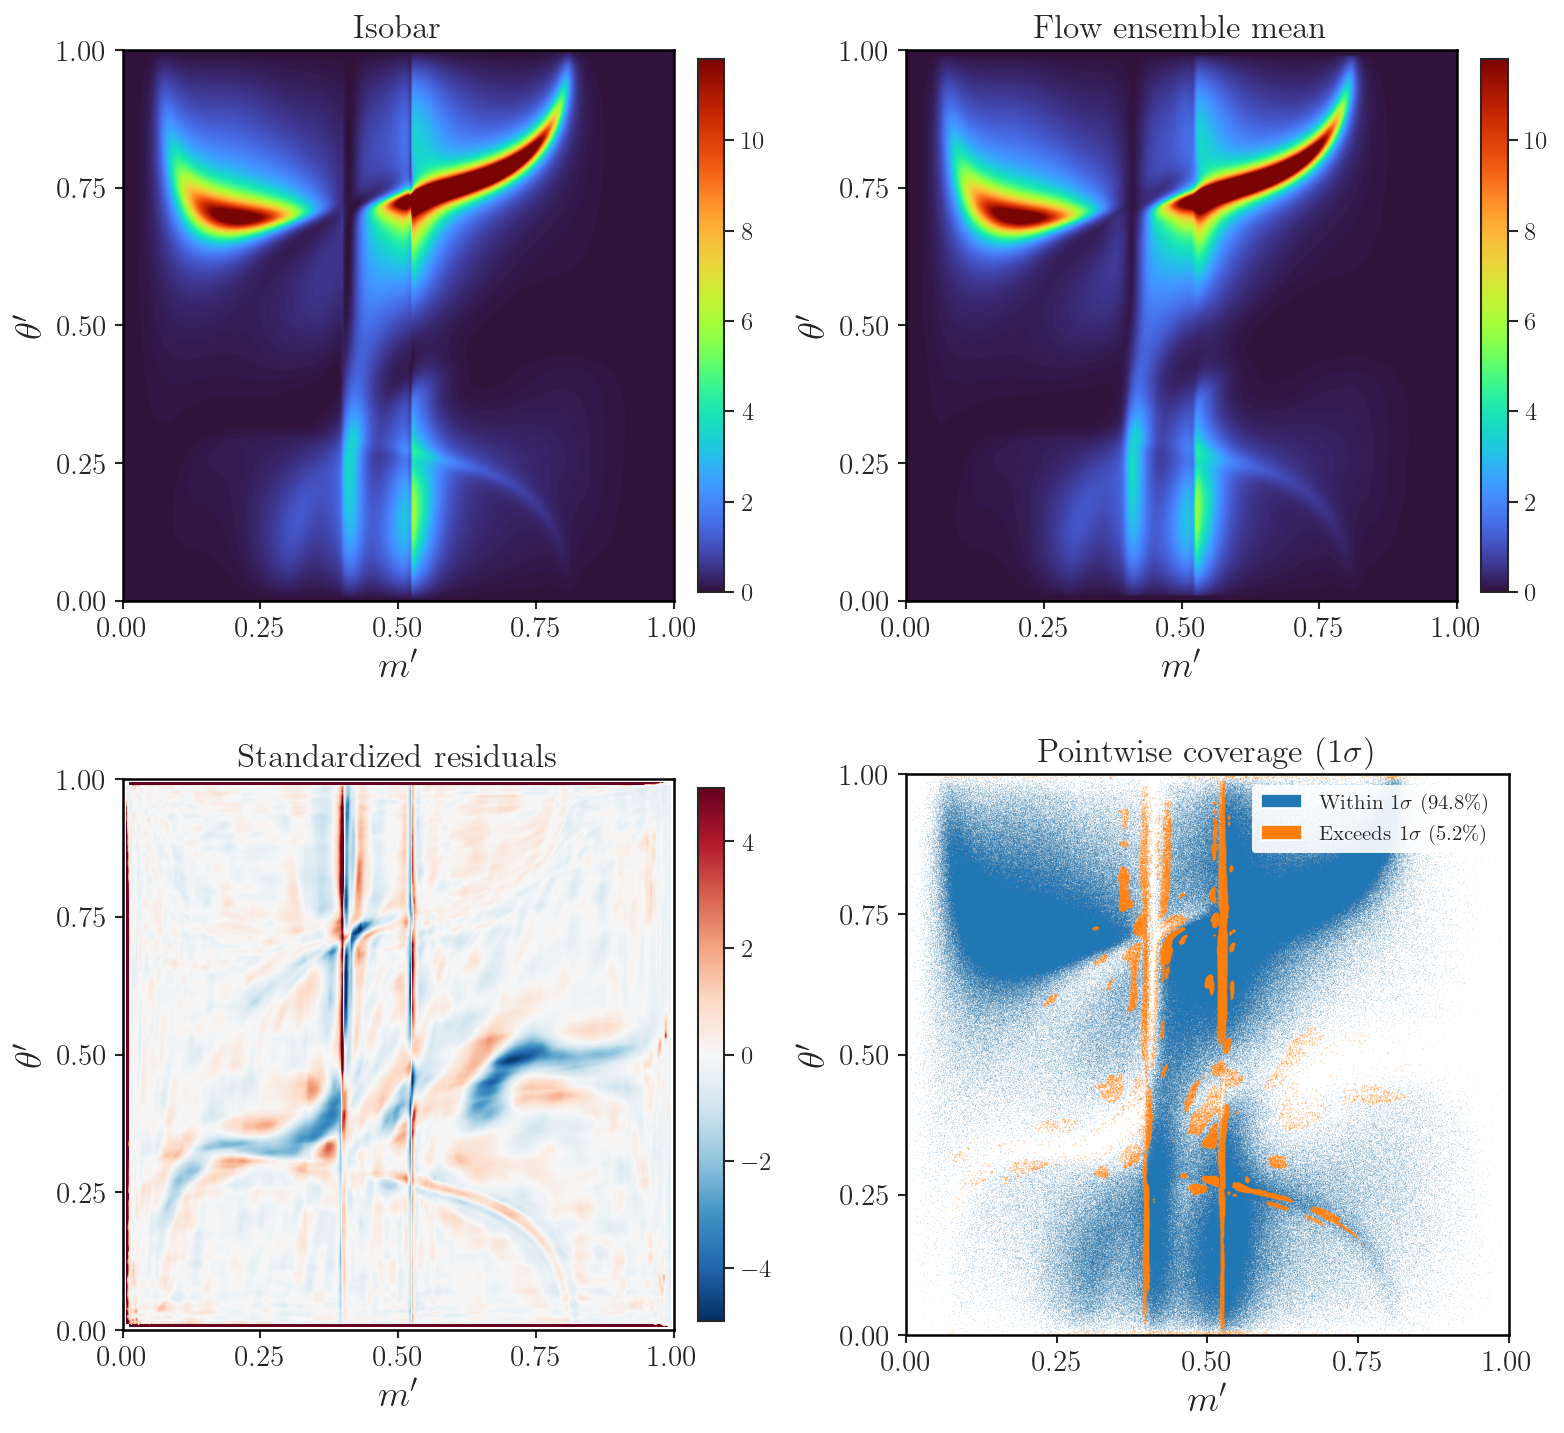

Saved: figure_paper/fig4_ensemble_4panel_flavor.pdf


In [11]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

def plot_ensemble_4panel(*, dens_iso, dens_flow, dens_flow_std, data_points,
                         valid_pts, exceeds_pts, savepath, iso_title='Isobar', flow_title='Flow ensemble mean'):
    fig = plt.figure(figsize=(11, 10), dpi=150)
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1],
                          wspace=0.30, hspace=0.30, left=0.08, right=0.92, top=0.94, bottom=0.08)
    ax_iso, ax_flow = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
    ax_z, ax_cov    = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

    extent = [0.0, 1.0, 0.0, 1.0]; tick_locs = [0.0, 0.25, 0.5, 0.75, 1.0]
    vmax = np.nanpercentile(np.concatenate([dens_iso.ravel(), dens_flow.ravel()]), 99)

    im1 = ax_iso.imshow(dens_iso,  origin='lower', extent=extent, cmap='turbo', vmin=0, vmax=vmax,
                        aspect='equal', interpolation='bilinear', rasterized=True)
    ax_iso.set_title(iso_title, fontsize=16)
    fig.colorbar(im1, ax=ax_iso, location='right', fraction=0.046, pad=0.04, shrink=0.95).ax.tick_params(labelsize=12)

    im2 = ax_flow.imshow(dens_flow, origin='lower', extent=extent, cmap='turbo', vmin=0, vmax=vmax,
                         aspect='equal', interpolation='bilinear', rasterized=True)
    ax_flow.set_title(flow_title, fontsize=16)
    fig.colorbar(im2, ax=ax_flow, location='right', fraction=0.046, pad=0.04, shrink=0.95).ax.tick_params(labelsize=12)

    valid_grid = dens_flow_std > 1e-10
    Z = np.full_like(dens_iso, np.nan)
    Z[valid_grid] = (dens_iso[valid_grid] - dens_flow[valid_grid]) / dens_flow_std[valid_grid]
    z_lim = min(5, np.nanpercentile(np.abs(Z[valid_grid]), 99))
    im3 = ax_z.imshow(Z, origin='lower', extent=extent, cmap='RdBu_r',
                      norm=TwoSlopeNorm(vcenter=0, vmin=-z_lim, vmax=z_lim),
                      aspect='equal', interpolation='bilinear', rasterized=True)
    ax_z.set_title('Standardized residuals', fontsize=16)
    fig.colorbar(im3, ax=ax_z, location='right', fraction=0.046, pad=0.04, shrink=0.95).ax.tick_params(labelsize=12)

    covered = np.zeros(len(data_points), dtype=bool); covered[valid_pts] = ~exceeds_pts
    not_cov = np.zeros(len(data_points), dtype=bool); not_cov[valid_pts] = exceeds_pts
    ax_cov.scatter(data_points[covered, 0], data_points[covered, 1], s=0.3, alpha=0.15, c='#1f77b4', rasterized=True, linewidths=0)
    ax_cov.scatter(data_points[not_cov, 0], data_points[not_cov, 1], s=0.5, alpha=0.3,  c='#ff7f0e', rasterized=True, linewidths=0)
    ax_cov.set_xlim(0, 1); ax_cov.set_ylim(0, 1)
    ax_cov.set_title(r'Pointwise coverage ($1\sigma$)', fontsize=16)
    n_cls = covered.sum() + not_cov.sum()
    pct_in, pct_out = covered.sum() / n_cls * 100, not_cov.sum() / n_cls * 100
    ax_cov.legend(handles=[
        Patch(facecolor='#1f77b4', label=f'Within $1\\sigma$ ({pct_in:.1f}\\%)'),
        Patch(facecolor='#ff7f0e', label=f'Exceeds $1\\sigma$ ({pct_out:.1f}\\%)'),
    ], loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)

    for ax in (ax_iso, ax_flow, ax_z, ax_cov):
        ax.set_xticks(tick_locs); ax.set_yticks(tick_locs)
        ax.set_xlabel(r"$m'$", fontsize=18); ax.set_ylabel(r"$\theta'$", fontsize=18)
        ax.tick_params(direction='out', length=4, width=1.0, labelsize=14)
        for sp in ax.spines.values():
            sp.set_linewidth(1.2); sp.set_color('black')

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {savepath}')


plot_ensemble_4panel(
    dens_iso=dens_exact_ens_2d, dens_flow=dens_ensemble_2d, dens_flow_std=dens_ensemble_std,
    data_points=data_pts, valid_pts=valid, exceeds_pts=exceeds_1sigma,
    savepath=str(FIG_DIR / f'fig4_ensemble_4panel_{FLOW_KIND}.pdf'),
)

## Figure 5 — CP-even ensemble 4-panel

Same layout as Figure 4 but for the **CP-even** flow ensemble, evaluated against the CP-even
isobar amplitude on the CP-even representative dataset.

Loading even ensemble: 100%|██████████| 25/25 [00:32<00:00,  1.29s/it]


Loaded CP-even training data: 2,000,000 points


Ensemble at even training pts: 100%|██████████| 25/25 [09:54<00:00, 23.79s/it]


CP-even f_cov = 0.9755 (97.55%)


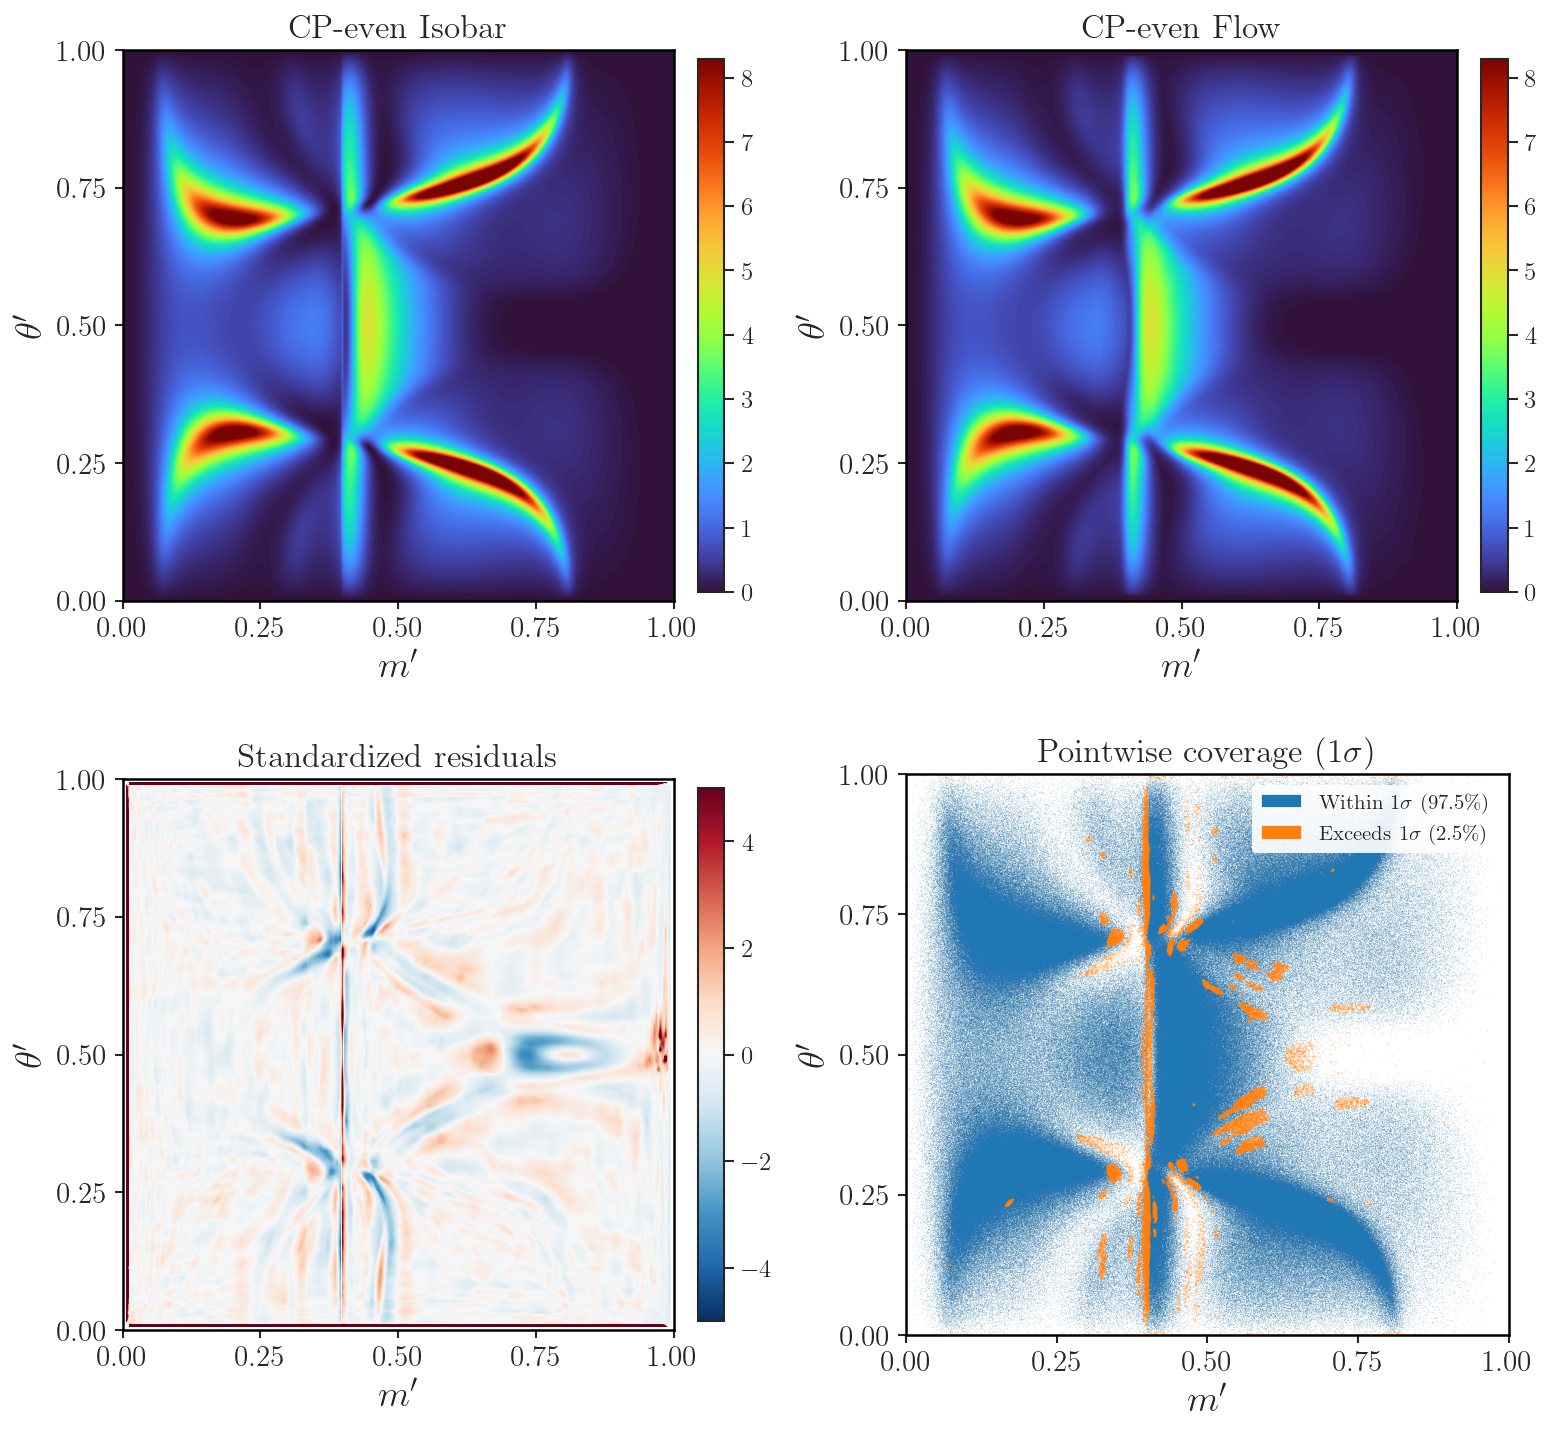

Saved: figure_paper/fig5_cp_even_4panel.pdf


In [12]:
mprime_e, theta_e, dens_even_flow_2d, dens_even_flow_std = compute_ensemble_density_grid(
    'even', n_grid=N_ENSEMBLE_GRID, n_seeds=N_SEEDS, device=device
)
_, _, dens_even_exact_2d = exact_density_grid('even', n_grid=N_ENSEMBLE_GRID)

even_data_pts = np.load('representative data/dataset_001_even.npy')
print(f'Loaded CP-even training data: {len(even_data_pts):,} points')
rho_iso_even = exact_sdp_density(even_data_pts, kind='even')
rho_mean_even, sigma_ens_even = ensemble_density_at_points('even', even_data_pts, n_seeds=N_SEEDS, device=device,
                                                           desc='Ensemble at even training pts')
valid_even = sigma_ens_even > 1e-15
exceeds_1sigma_even = np.abs(rho_iso_even[valid_even] - rho_mean_even[valid_even]) > sigma_ens_even[valid_even]
f_cov_even = np.mean(~exceeds_1sigma_even)
print(f'CP-even f_cov = {f_cov_even:.4f} ({f_cov_even*100:.2f}%)')

plot_ensemble_4panel(
    dens_iso=dens_even_exact_2d, dens_flow=dens_even_flow_2d, dens_flow_std=dens_even_flow_std,
    data_points=even_data_pts, valid_pts=valid_even, exceeds_pts=exceeds_1sigma_even,
    iso_title='CP-even Isobar', flow_title='CP-even Flow',
    savepath=str(FIG_DIR / 'fig5_cp_even_4panel.pdf'),
)

## Figure 6 — CP-odd ensemble 4-panel

Same layout as Figure 4 but for the **CP-odd** flow ensemble.

Loading odd ensemble: 100%|██████████| 25/25 [00:33<00:00,  1.33s/it]


Loaded CP-odd training data: 2,000,000 points


Ensemble at odd training pts: 100%|██████████| 25/25 [09:51<00:00, 23.68s/it]


CP-odd f_cov = 0.9602 (96.02%)


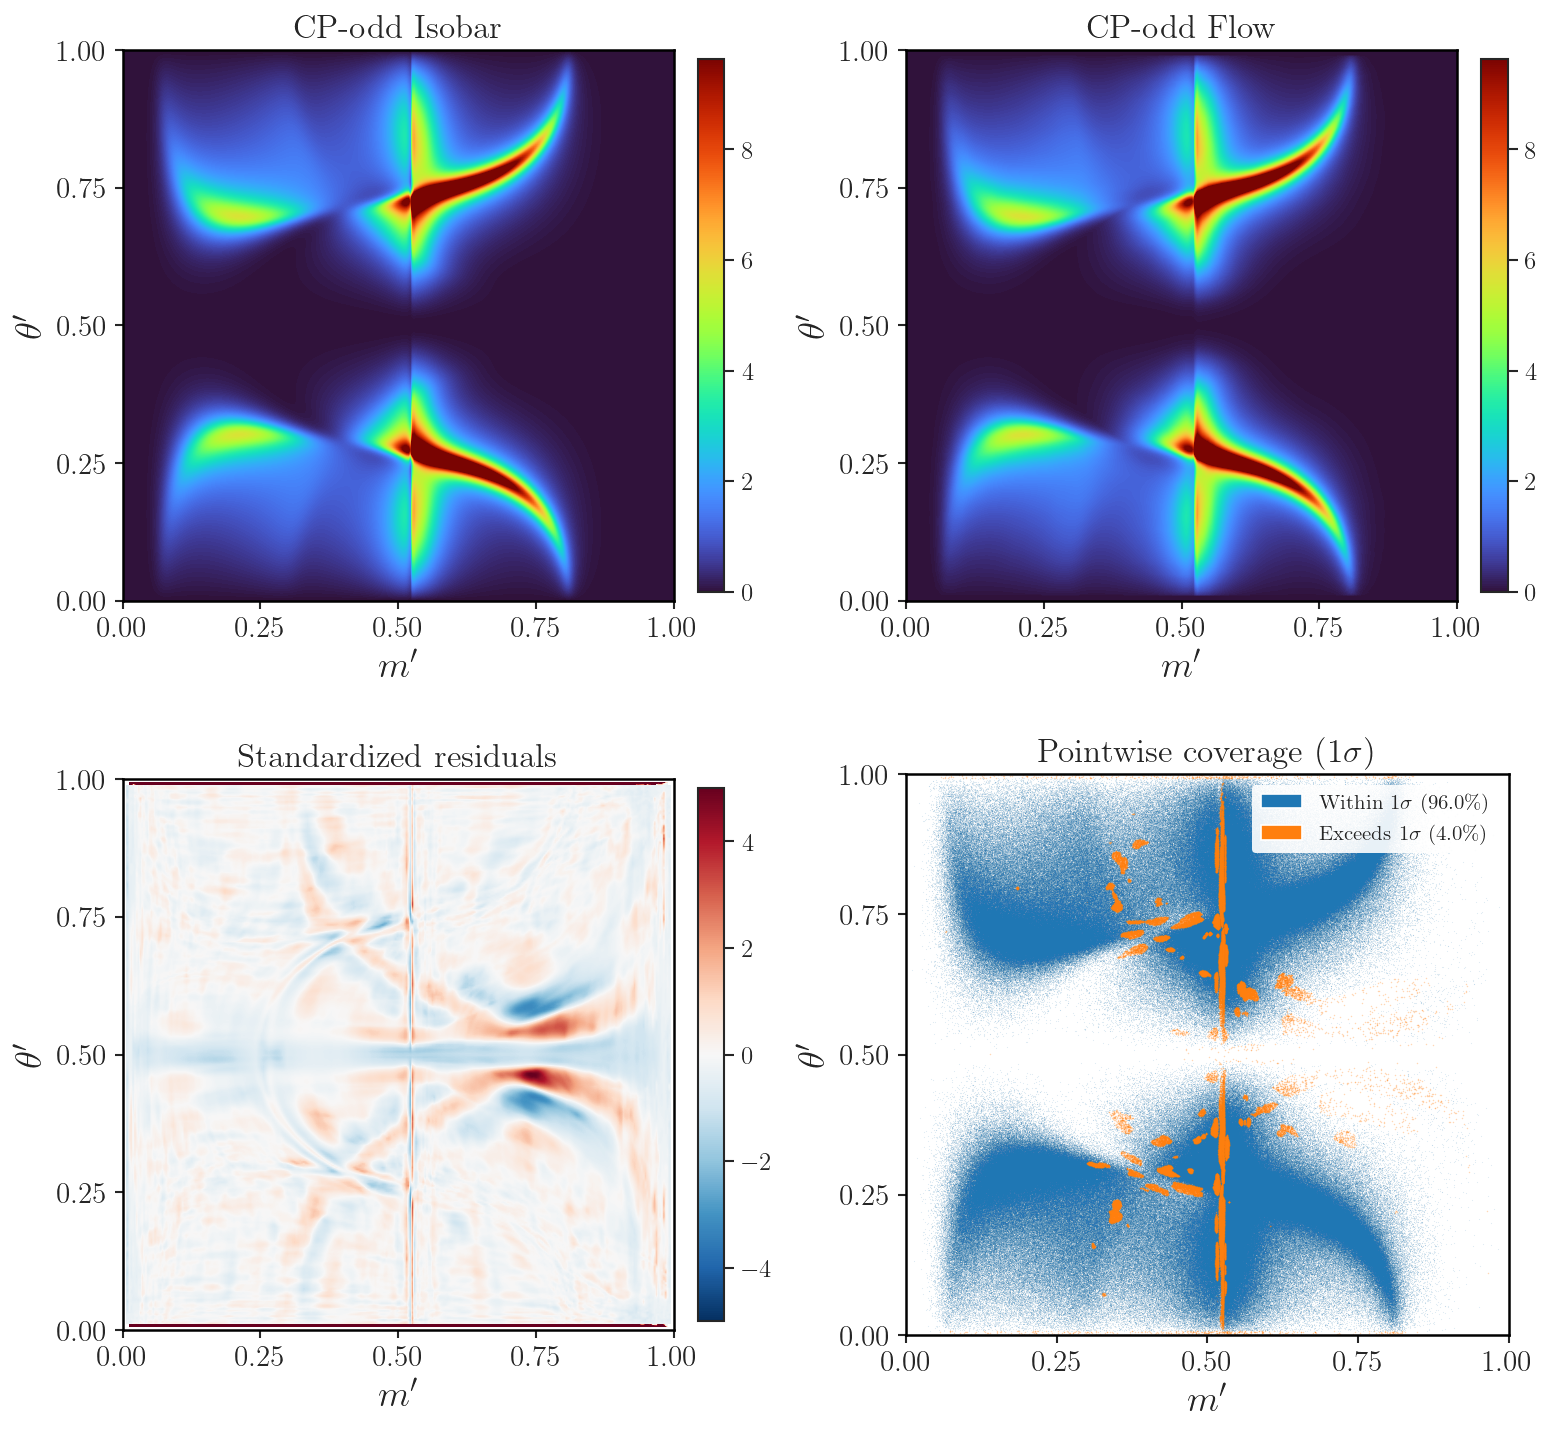

Saved: figure_paper/fig6_cp_odd_4panel.pdf


In [13]:
mprime_o, theta_o, dens_odd_flow_2d, dens_odd_flow_std = compute_ensemble_density_grid(
    'odd', n_grid=N_ENSEMBLE_GRID, n_seeds=N_SEEDS, device=device
)
_, _, dens_odd_exact_2d = exact_density_grid('odd', n_grid=N_ENSEMBLE_GRID)

odd_data_pts = np.load('representative data/dataset_001_odd.npy')
print(f'Loaded CP-odd training data: {len(odd_data_pts):,} points')
rho_iso_odd = exact_sdp_density(odd_data_pts, kind='odd')
rho_mean_odd, sigma_ens_odd = ensemble_density_at_points('odd', odd_data_pts, n_seeds=N_SEEDS, device=device,
                                                         desc='Ensemble at odd training pts')
valid_odd = sigma_ens_odd > 1e-15
exceeds_1sigma_odd = np.abs(rho_iso_odd[valid_odd] - rho_mean_odd[valid_odd]) > sigma_ens_odd[valid_odd]
f_cov_odd = np.mean(~exceeds_1sigma_odd)
print(f'CP-odd f_cov = {f_cov_odd:.4f} ({f_cov_odd*100:.2f}%)')

plot_ensemble_4panel(
    dens_iso=dens_odd_exact_2d, dens_flow=dens_odd_flow_2d, dens_flow_std=dens_odd_flow_std,
    data_points=odd_data_pts, valid_pts=valid_odd, exceeds_pts=exceeds_1sigma_odd,
    iso_title='CP-odd Isobar', flow_title='CP-odd Flow',
    savepath=str(FIG_DIR / 'fig6_cp_odd_4panel.pdf'),
)